传统方法
基于统计模型的语音增强（statistical model-based speech enhancement）
短时谱衰减法（STSA, Short-Time Spectral Attenuation）

In [1]:
from scipy.io import wavfile
from IPython.display import Audio, display

def save(name, sig, sr=16000):
    sig = np.clip(sig, -1, 0.99997)
    wavfile.write(name, sr, (sig * 32768).astype(np.int16))

def listen(sig, name=None, sr=16000):
    if name:
        save(name, sig, sr)
    display(Audio(np.clip(sig, -1, 0.99997), rate=sr))

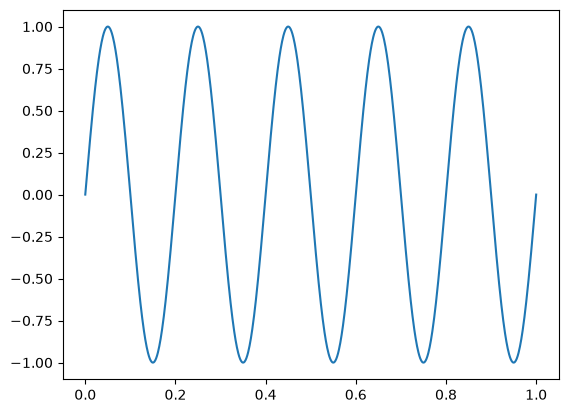

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 1000)      # 0到1秒之间取1000个时间点
x = np.sin(2 * np.pi * 5 * t)    # 5 Hz 正弦波
plt.plot(t, x)
plt.show()

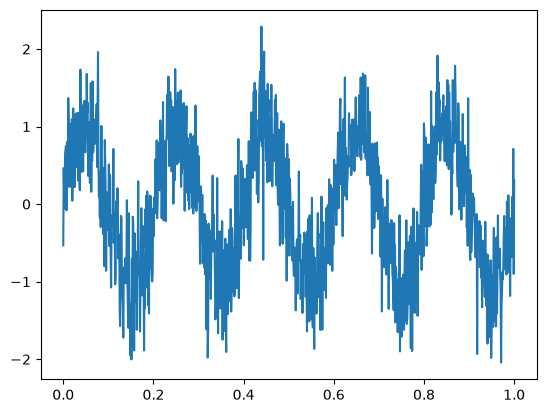

In [3]:
noise = 0.5 * np.random.randn(1000)   # 1000个随机数
y = x + noise                          # 直接相加，整个向量一起算
plt.plot(t, y)
plt.show()

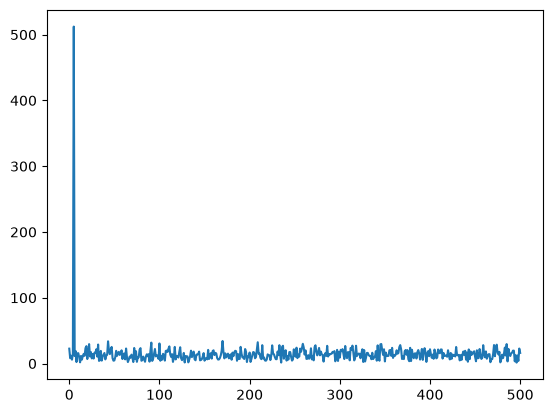

In [4]:
spec = np.abs(np.fft.rfft(y))    # 做傅里叶变换，取幅度
plt.plot(spec)
plt.show()

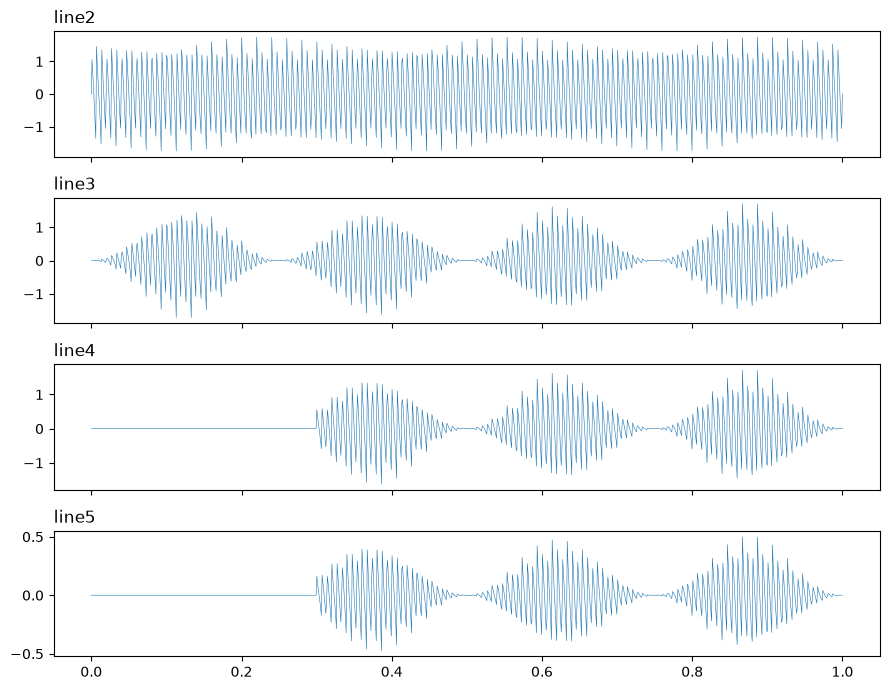

In [5]:
fig, ax = plt.subplots(4, 1, figsize=(9, 7), sharex=True)

a = sum(np.sin(2*np.pi*150*k*t)/k for k in range(1, 15))
b = a * np.sin(2*np.pi*2*t)**2
c = b.copy();  c[t < 0.3] = 0
d = c / np.max(np.abs(c)) * 0.5

for i, (sig, name) in enumerate(zip([a, b, c, d],
        ["line2", "line3", "line4", "line5"])):
    ax[i].plot(t, sig, lw=0.4)
    ax[i].set_title(name, loc="left")
plt.tight_layout()
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, istft
from scipy.io import wavfile

sr = 16000                                    # 采样率
t  = np.arange(0, 2, 1/sr)                    # 2 秒的时间轴

x = sum(np.sin(2*np.pi*150*k*t)/k for k in range(1, 15))  # 150Hz + 谐波，看上图line2
x = x * np.sin(2*np.pi*2*t)**2                # 乘起伏包络，像在"说话"，看上图line3
x[t < 0.3] = 0                                # 前 0.3 秒静音（重要，后面解释），看上图line4
x = x / np.max(np.abs(x)) * 0.5               # 音量归一化

print(x.shape)                                # 应该输出 (32000,)

(32000,)


(201, 201)


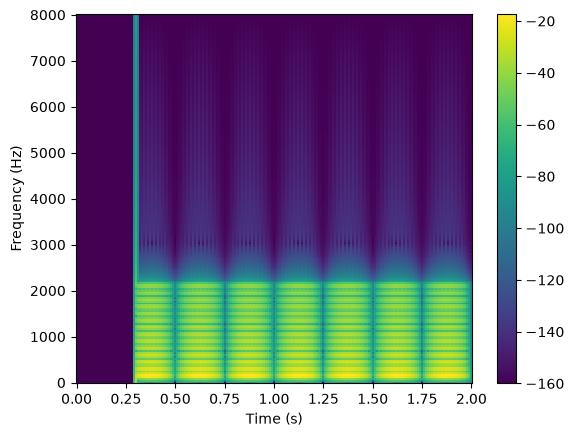

In [8]:
# 绘制语谱图
f, tt, X = stft(x, sr, nperseg=400, noverlap=240)   # 波形 → 频谱

print(X.shape)          # (201, 201)

plt.pcolormesh(tt, f, 20*np.log10(np.abs(X) + 1e-8), shading="auto")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.colorbar()  #最右边是色标
plt.show()

In [9]:
noise = 0.15 * np.random.randn(len(x))    # 生成噪声
noisy = x + noise                          # 混合

print(noisy.shape)                         # (32000,) 确认还是数组

(32000,)


In [10]:
from IPython.display import Audio, display

display(Audio(x,     rate=sr))    # 干净的
display(Audio(noisy, rate=sr))    # 带噪的

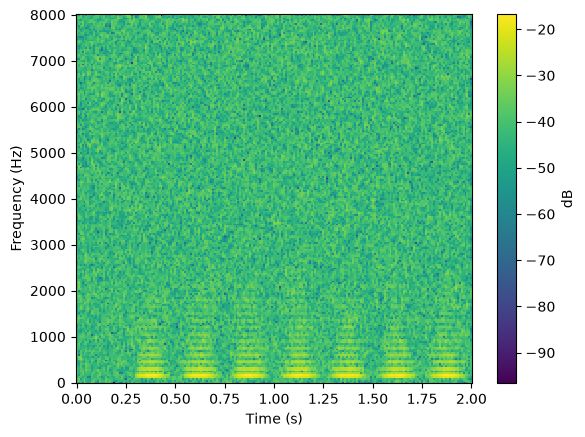

In [11]:
f, tt, Xn = stft(noisy, sr, nperseg=400, noverlap=240)
S = 20*np.log10(np.abs(Xn) + 1e-8)

plt.pcolormesh(tt, f, S, shading="auto", vmin=S.max()-80, vmax=S.max())
plt.ylabel("Frequency (Hz)"); plt.xlabel("Time (s)")
plt.colorbar(label="dB"); plt.show()

# 噪声不是均匀地损害所有地方。强的谐波依然清晰，弱的被埋掉了。
# 降噪算法能工作，靠的就是这个差异——留下明显高于噪声的，压掉接近噪声的。

In [12]:
snr = 10 * np.log10(np.mean(x**2) / np.mean(noise**2))
print(f"SNR = {snr:.1f} dB")

SNR = -0.3 dB


In [13]:
# 只在有语音的地方算 SNR
mask = np.abs(x) > 0.01
snr_speech = 10*np.log10(np.mean(x[mask]**2) / np.mean(noise[mask]**2))
print(f"整段 SNR = {snr:.1f} dB,  仅语音段 SNR = {snr_speech:.1f} dB")

整段 SNR = -0.3 dB,  仅语音段 SNR = 1.4 dB


In [ ]:
# 降噪：谱减法（1979年）
f, tt, Xn = stft(noisy, sr, nperseg=400, noverlap=240)   # ① 带噪信号 → 频谱

power = np.abs(Xn)**2                                     # ② 每个时频点的能量
noise_power = np.mean(power[:, :25], axis=1, keepdims=True)  # ③ 估计噪声

gain = np.maximum(1 - noise_power / (power + 1e-10), 0.1)    # ④ 算增益
Y = Xn * gain                                                # ⑤ 频谱 × 增益

_, y = istft(Y, sr, nperseg=400, noverlap=240)               # ⑥ 频谱 → 波形
print(y.shape)

(32000,)


In [15]:
from IPython.display import Audio, display

display(Audio(x,     rate=sr))     # 干净的
display(Audio(noisy, rate=sr))     # 降噪前
display(Audio(y,     rate=sr))     # 降噪后

In [16]:
snr_before = 10*np.log10(np.mean(x**2) / np.mean((noisy - x)**2))
snr_after  = 10*np.log10(np.mean(x**2) / np.mean((y[:len(x)] - x)**2))
print(f"SNR: {snr_before:.2f} dB -> {snr_after:.2f} dB   提升 {snr_after-snr_before:.2f} dB")

SNR: -0.27 dB -> 5.57 dB   提升 5.84 dB


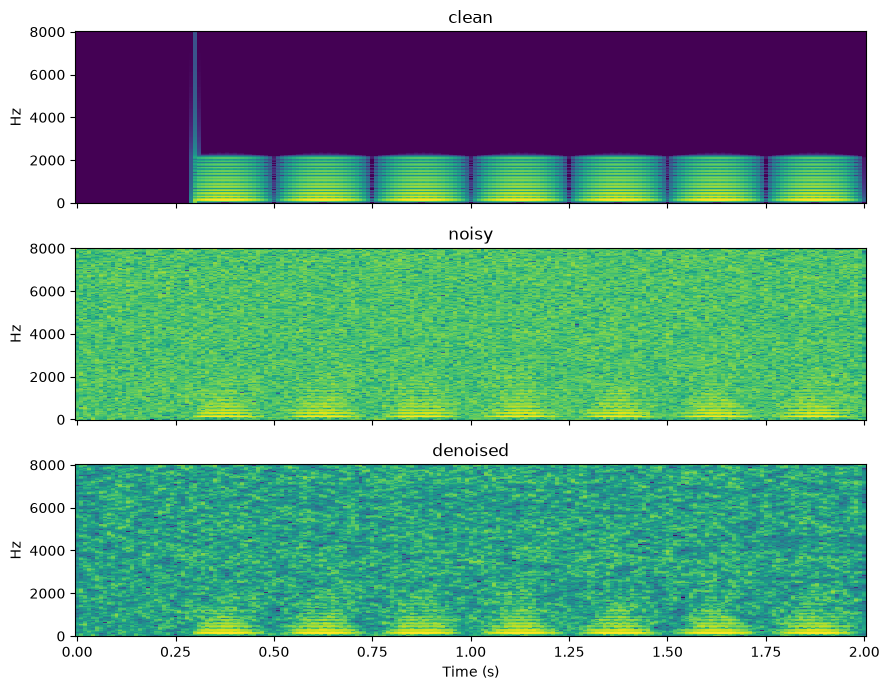

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)

for ax, sig, name in zip(axes, [x, noisy, y[:len(x)]], ["clean", "noisy", "denoised"]):
    ff, ttt, S = stft(sig, sr, nperseg=400, noverlap=240)
    S_db = 20*np.log10(np.abs(S) + 1e-8)
    im = ax.pcolormesh(ttt, ff, S_db, shading="auto", vmin=-100, vmax=-20)
    ax.set_title(name)
    ax.set_ylabel("Hz")

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

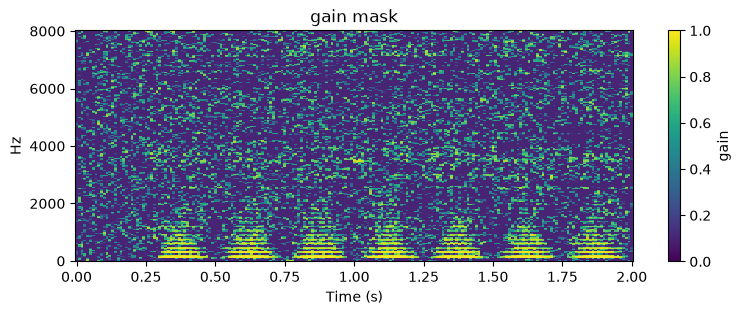

In [ ]:
plt.figure(figsize=(9,3))
plt.pcolormesh(tt, f, gain, shading="auto", vmin=0, vmax=1, cmap="viridis")
plt.xlabel("Time (s)"); plt.ylabel("Hz")
plt.colorbar(label="gain")
plt.title("gain mask")
plt.show()  #展示增益谱图

In [ ]:
# 降噪法2：维纳+判决引导（1984年提出）
f, tt, Xn = stft(noisy, sr, nperseg=400, noverlap=240)
power = np.abs(Xn)**2
noise_power = np.mean(power[:, :25], axis=1, keepdims=True)   # 前25帧当噪声

alpha = 0.98                      # 判决引导的平滑系数
G = np.zeros_like(power)          # 存放每一帧的增益
G_prev = None                     # 上一帧的增益
gamma_prev = None                 # 上一帧的后验信噪比

for i in range(power.shape[1]):                    # 逐帧处理
    gamma = power[:, i] / noise_power[:, 0]        # 后验信噪比

    if G_prev is None:                             # 第一帧没有历史，用粗估计
        xi = np.maximum(gamma - 1, 0)
    else:
        xi = alpha * G_prev**2 * gamma_prev + (1-alpha) * np.maximum(gamma - 1, 0)  #判决引导公式

    xi = np.maximum(xi, 1e-6)                      # 防止除零
    g = xi / (1 + xi)                              # 维纳增益

    G[:, i] = g
    G_prev, gamma_prev = g, gamma                  # 存给下一帧用

_, y_w = istft(Xn * G, sr, nperseg=400, noverlap=240)

In [23]:
listen(x,           "clean.wav")
listen(noisy,           "noisy.wav")
listen(y[:len(x)],   "denoised_specsub.wav")   # 谱减法（旧块4的结果）
listen(y_w[:len(x)],    "denoised_wiener.wav")    # 新的

已保存 clean.wav


已保存 noisy.wav


已保存 denoised_specsub.wav


已保存 denoised_wiener.wav


In [24]:
# 上述两个方法需要假设开头 0.25 秒一定没人说话，而且噪声从头到尾一成不变。
# 真实场景两条都不成立，故引出法3
# 法3：2001年Martin提出：最小值统计
def estimate_noise_minstat(power, win=100, alpha_s=0.9, bias=1.6):
    """
    最小值统计噪声估计
    win     : 求最小值的窗长(帧)，100帧=1秒
    alpha_s : 功率谱平滑系数
    bias    : 偏差补偿，最小值必然低估
    """
    n_freq, n_frames = power.shape
    noise = np.zeros_like(power)
    S = power[:, 0].copy()          # 平滑后的功率谱，取第 0 帧的全部 201 个频点，形状 (201,)，作为平滑器的初值。
    buf = []                        # 普通的 Python 列表，用来存"最近 win 帧的历史"。这就是滑动窗

    for i in range(n_frames):
        S = alpha_s * S + (1 - alpha_s) * power[:, i]     # ① 一阶递归平滑，抹掉随机抖动，只留下缓慢变化的趋势
        buf.append(S.copy())
        if len(buf) > win:
            buf.pop(0)                                     # ② 只保留最近win帧，队列长度始终不超过win，新的进、旧的出
        noise[:, i] = bias * np.min(np.stack(buf), axis=0) # ③ 取最小值 × 补偿
        # np.stack(buf) — 把列表里的 100 个 (201,) 数组堆成一个二维数组 (100, 201)。
        # np.min(..., axis=0) — 沿着第 0 维（帧方向）求最小，得到 (201,)。
        # 对每个频点，在最近 100 帧里挑出最小的那个值
        # bias * — 乘 1.6 做补偿。最小值必然低于平均值，不补回来会低估噪声。

    return noise

In [25]:
noise_est = estimate_noise_minstat(power)     # 现在是二维的，逐帧变化，估计的噪声

alpha = 0.98
G = np.zeros_like(power)
G_prev = gamma_prev = None

for i in range(power.shape[1]):
    gamma = power[:, i] / np.maximum(noise_est[:, i], 1e-12)   # ← 用当前帧的噪声估计
    if G_prev is None:
        xi = np.maximum(gamma - 1, 0)
    else:
        xi = alpha * G_prev**2 * gamma_prev + (1-alpha) * np.maximum(gamma - 1, 0)
    xi = np.maximum(xi, 1e-6)
    g = xi / (1 + xi)
    G[:, i] = g
    G_prev, gamma_prev = g, gamma

_, y_adapt = istft(Xn * G, sr, nperseg=400, noverlap=240)

参数	            调大的后果	                调小的后果
win（窗长）	        估计更稳，但跟踪更慢	    跟踪快，但容易把语音当噪声（尤其长元音）
alpha_s（平滑）	    抖动小，反应慢	            反应快，估计噪
bias（补偿）	    抑制更狠，语音失真↑	        抑制不足，残留噪声↑

In [30]:
# ===== 6秒信号，噪声在第3秒后涨 10 dB =====
sr  = 16000
dur = 6.0
t   = np.arange(0, dur, 1/sr)

# 语音（和之前一样，只是变长）
x = np.zeros(len(t))
for k in range(1, 15):
    x = x + np.sin(2*np.pi*150*k*t) / k
x = x * np.sin(2*np.pi*2*t)**2
x[t < 0.3] = 0
x = x / np.max(np.abs(x)) * 0.5

# 噪声：音量随时间上升（S形，中心在第3秒）
rng   = np.random.default_rng(0)
level = 0.15 * (1 + 2.2/(1 + np.exp(-(t - 3.0)*4)))    # 0.15 -> 0.48
noise = level * rng.standard_normal(len(t))
noisy = x + noise

# 重新做 STFT
f, tt, Xn = stft(noisy, sr, nperseg=400, noverlap=240)
power = np.abs(Xn)**2

print("power.shape =", power.shape)      # 应该是 (201, 601)

power.shape = (201, 601)


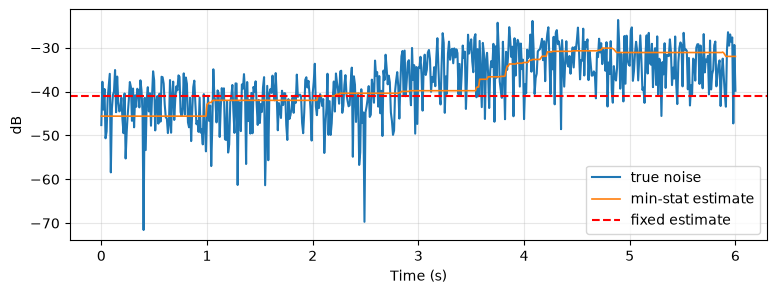

In [31]:
# --- 补齐可能缺的变量 ---
Nt = np.abs(stft(noise, sr, nperseg=400, noverlap=240)[2])**2      # 真实噪声(仅实验可知)
fixed = np.repeat(np.mean(power[:, :25], axis=1, keepdims=True),
                  power.shape[1], axis=1)                           # 固定估计
noise_est = estimate_noise_minstat(power)                           # 最小值统计

# --- 画图 ---
k = 100                                        # 第100个频点，约 4000 Hz

plt.figure(figsize=(9,3))
plt.plot(tt, 10*np.log10(Nt[k] + 1e-12),        lw=1.5, label="true noise")
plt.plot(tt, 10*np.log10(noise_est[k] + 1e-12), lw=1.2, label="min-stat estimate")
plt.axhline(10*np.log10(fixed[k, 0]), ls="--", c="r", label="fixed estimate")
plt.xlabel("Time (s)"); plt.ylabel("dB")
plt.legend(); plt.grid(alpha=.3)
plt.show()

In [32]:
# ===== 三种噪声估计，跑同一个维纳+判决引导 =====

def wiener_dd(power, Xn, noise_mat, alpha=0.98):
    """noise_mat 形状必须是 (201, 帧数)"""
    G = np.zeros_like(power)
    G_prev = gamma_prev = None
    for i in range(power.shape[1]):
        gamma = power[:, i] / np.maximum(noise_mat[:, i], 1e-12)
        if G_prev is None:
            xi = np.maximum(gamma - 1, 0)
        else:
            xi = alpha * G_prev**2 * gamma_prev + (1-alpha) * np.maximum(gamma - 1, 0)
        xi = np.maximum(xi, 1e-6)
        g = xi / (1 + xi)
        G[:, i] = g
        G_prev, gamma_prev = g, gamma
    _, y = istft(Xn * G, sr, nperseg=400, noverlap=240)
    return y, G

y_fix, G_fix = wiener_dd(power, Xn, fixed)        # 固定估计
y_ms,  G_ms  = wiener_dd(power, Xn, noise_est)    # 最小值统计
y_god, G_god = wiener_dd(power, Xn, Nt)           # 上帝视角（理论上限）

def snr(e, a=0, b=None):
    b = b or len(x)
    e = e[:len(x)]
    return 10*np.log10(np.mean(x[a:b]**2) / np.mean((e[a:b]-x[a:b])**2))

h = int(3.5*sr)
print(f"{'':16s}{'整段':>8s}{'前3秒':>8s}{'后3秒':>8s}")
for name, y_ in [("带噪", noisy), ("固定估计", y_fix),
                 ("最小值统计", y_ms), ("上帝视角", y_god)]:
    print(f"{name:16s}{snr(y_):8.2f}{snr(y_,0,h):8.2f}{snr(y_,h):8.2f}")

                      整段     前3秒     后3秒
带噪                 -7.19   -3.19   -9.70
固定估计               -3.97    3.40   -7.11
最小值统计               0.38    0.91   -0.22
上帝视角                6.99    9.18    5.19


In [33]:
listen(x,            "clean6.wav")
listen(noisy,        "noisy6.wav")
listen(y_fix[:len(x)], "fix6.wav")
listen(y_ms[:len(x)],  "minstat6.wav")
listen(y_god[:len(x)], "god6.wav")

已保存 clean6.wav


已保存 noisy6.wav


已保存 fix6.wav


已保存 minstat6.wav


已保存 god6.wav


In [34]:
for win in [30, 100, 200]:
    ne = estimate_noise_minstat(power, win=win)
    y_, _ = wiener_dd(power, Xn, ne)
    print(f"win={win:3d} ({win/100:.1f}秒)  后3秒 SNR = {snr(y_, h):5.2f} dB")
    listen(y_[:len(x)])

win= 30 (0.3秒)  后3秒 SNR =  0.19 dB


win=100 (1.0秒)  后3秒 SNR = -0.22 dB


win=200 (2.0秒)  后3秒 SNR = -3.66 dB
